# 1.Human Activity Recognition Using Smartphones

## 2. Exploratory Data Analysis

### 2.1 Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)

In [2]:
DATA_DIR = "."

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print("Training data loaded:", train_df.shape)
print("Test data loaded:    ", test_df.shape)

Training data loaded: (7352, 563)
Test data loaded:     (2947, 563)


In [3]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,...,"angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.2886,-0.0203,-0.1329,-0.9953,-0.9831,-0.9135,...,-0.0184,-0.8412,0.1799,-0.0586,1,STANDING
1,0.2784,-0.0164,-0.1235,-0.9982,-0.9753,-0.9603,...,0.7035,-0.8448,0.1803,-0.0543,1,STANDING
2,0.2797,-0.0195,-0.1135,-0.9954,-0.9672,-0.9789,...,0.8085,-0.8489,0.1806,-0.0491,1,STANDING
3,0.2792,-0.0262,-0.1233,-0.9961,-0.9834,-0.9907,...,-0.4854,-0.8486,0.1819,-0.0477,1,STANDING
4,0.2766,-0.0166,-0.1154,-0.9981,-0.9808,-0.9905,...,-0.6160,-0.8479,0.1852,-0.0439,1,STANDING


In [4]:
test_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,...,"angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.2572,-0.0233,-0.0147,-0.9384,-0.9201,-0.6677,...,0.2712,-0.7200,0.2768,-0.0580,2,STANDING
1,0.2860,-0.0132,-0.1191,-0.9754,-0.9675,-0.9450,...,0.9206,-0.6981,0.2813,-0.0839,2,STANDING
2,0.2755,-0.0261,-0.1182,-0.9938,-0.9699,-0.9627,...,0.1451,-0.7028,0.2801,-0.0793,2,STANDING
3,0.2703,-0.0326,-0.1175,-0.9947,-0.9733,-0.9671,...,0.2964,-0.6990,0.2841,-0.0771,2,STANDING
4,0.2748,-0.0278,-0.1295,-0.9939,-0.9674,-0.9783,...,-0.1185,-0.6922,0.2907,-0.0739,2,STANDING


### 2.2 Dataset Dimensions

In [5]:
TARGET = "Activity"
feature_columns = [c for c in train_df.columns if c not in (TARGET, "subject")]

print(f"Train rows (windows): {train_df.shape[0]}")
print(f"Test rows (windows):  {test_df.shape[0]}")
print(f"Total columns:        {train_df.shape[1]}")
print(f"Sensor feature columns: {len(feature_columns)}  (+ 'subject' + '{TARGET}')")
print(f"Train share of all rows: {len(train_df) / (len(train_df) + len(test_df)):.2%}")
print("Same columns in train and test:", list(train_df.columns) == list(test_df.columns))

Train rows (windows): 7352
Test rows (windows):  2947
Total columns:        563
Sensor feature columns: 561  (+ 'subject' + 'Activity')
Train share of all rows: 71.39%
Same columns in train and test: True


### 2.3 Data Types and Summary Statistics

In [6]:
print("Column data types (count):")
print(train_df.dtypes.value_counts())
print()
print("Non-numeric columns:", list(train_df.select_dtypes(exclude="number").columns))

Column data types (count):
float64    561
int64        1
str          1
Name: count, dtype: int64

Non-numeric columns: ['Activity']


In [7]:
selected_features = [
    "tBodyAcc-mean()-X", "tBodyAcc-std()-X", "tGravityAcc-mean()-X",
    "tBodyAccMag-mean()", "tBodyGyroMag-mean()", "angle(X,gravityMean)",
]
train_df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.2745,0.0703,-1.0,0.2630,0.2772,0.2885,1.0000
tBodyAcc-std()-X,7352.0,-0.6054,0.4487,-1.0,-0.9928,-0.9462,-0.2428,1.0000
tGravityAcc-mean()-X,7352.0,0.6641,0.5168,-1.0,0.8049,0.9195,0.9531,0.9915
tBodyAccMag-mean(),7352.0,-0.5439,0.4777,-1.0,-0.9833,-0.8834,-0.1069,1.0000
tBodyGyroMag-mean(),7352.0,-0.6029,0.4078,-1.0,-0.9800,-0.8345,-0.2329,1.0000
"angle(X,gravityMean)",7352.0,-0.4895,0.5118,-1.0,-0.8121,-0.7094,-0.5091,1.0000


In [8]:
overall_min = train_df[feature_columns].min().min()
overall_max = train_df[feature_columns].max().max()
print(f"Minimum value across all training features: {overall_min:.4f}")
print(f"Maximum value across all training features: {overall_max:.4f}")

Minimum value across all training features: -1.0000
Maximum value across all training features: 1.0000


### 2.4 Missing Values

In [9]:
print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test: ", test_df.isnull().sum().sum())

Missing values in train: 0
Missing values in test:  0


### 2.5 Duplicate Analysis

In [10]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test: ", test_df.duplicated().sum())

duplicate_feature_cols = train_df[feature_columns].T.duplicated().sum()
print("Feature columns that exactly duplicate another column:", duplicate_feature_cols)

train_subjects = set(train_df["subject"])
test_subjects = set(test_df["subject"])
print(f"\nSubjects in train: {len(train_subjects)} -> {sorted(train_subjects)}")
print(f"Subjects in test:  {len(test_subjects)} -> {sorted(test_subjects)}")
print("Subjects appearing in BOTH sets:", sorted(train_subjects & test_subjects))

Duplicate rows in train: 0
Duplicate rows in test:  0


Feature columns that exactly duplicate another column: 21

Subjects in train: 21 -> [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
Subjects in test:  9 -> [2, 4, 9, 10, 12, 13, 18, 20, 24]
Subjects appearing in BOTH sets: []


### 2.6 Activity Distribution

In [11]:
activity_classes = sorted(train_df[TARGET].unique())
print("Activity classes present in the data:", activity_classes)
print("Number of classes:", len(activity_classes))
print("Test set has the same classes:", activity_classes == sorted(test_df[TARGET].unique()))

class_distribution = pd.DataFrame({
    "Train count": train_df[TARGET].value_counts(),
    "Train %": train_df[TARGET].value_counts(normalize=True) * 100,
    "Test count": test_df[TARGET].value_counts(),
    "Test %": test_df[TARGET].value_counts(normalize=True) * 100,
}).round(2)
class_distribution

Activity classes present in the data: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Number of classes: 6
Test set has the same classes: True


,Train count,Train %,Test count,Test %
Activity,,,,
LAYING,1407,19.14,537,18.22
SITTING,1286,17.49,491,16.66
STANDING,1374,18.69,532,18.05
WALKING,1226,16.68,496,16.83
WALKING_DOWNSTAIRS,986,13.41,420,14.25
WALKING_UPSTAIRS,1073,14.59,471,15.98


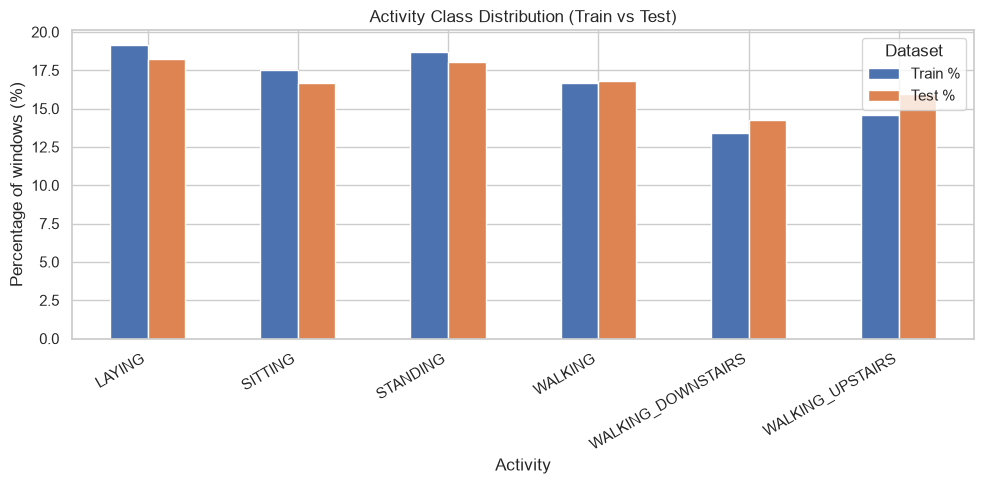

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
class_distribution[["Train %", "Test %"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Activity Class Distribution (Train vs Test)")
ax.set_xlabel("Activity")
ax.set_ylabel("Percentage of windows (%)")
ax.legend(title="Dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 2.7 Feature Distributions

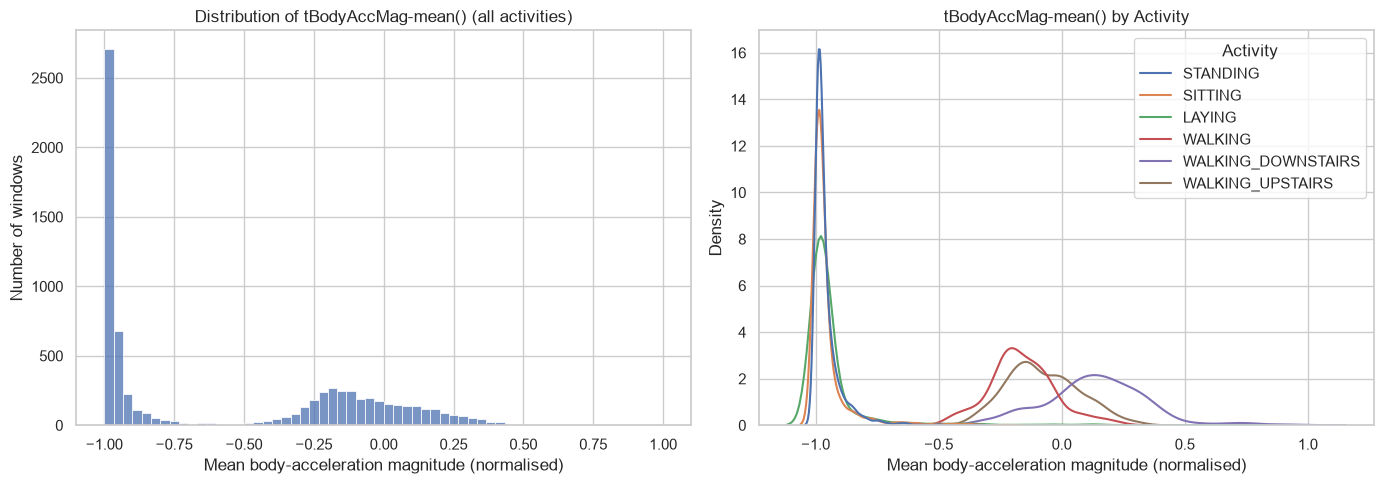

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x="tBodyAccMag-mean()", bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of tBodyAccMag-mean() (all activities)")
axes[0].set_xlabel("Mean body-acceleration magnitude (normalised)")
axes[0].set_ylabel("Number of windows")

sns.kdeplot(data=train_df, x="tBodyAccMag-mean()", hue=TARGET, common_norm=False, ax=axes[1])
axes[1].set_title("tBodyAccMag-mean() by Activity")
axes[1].set_xlabel("Mean body-acceleration magnitude (normalised)")
axes[1].set_ylabel("Density")
plt.tight_layout()
plt.show()

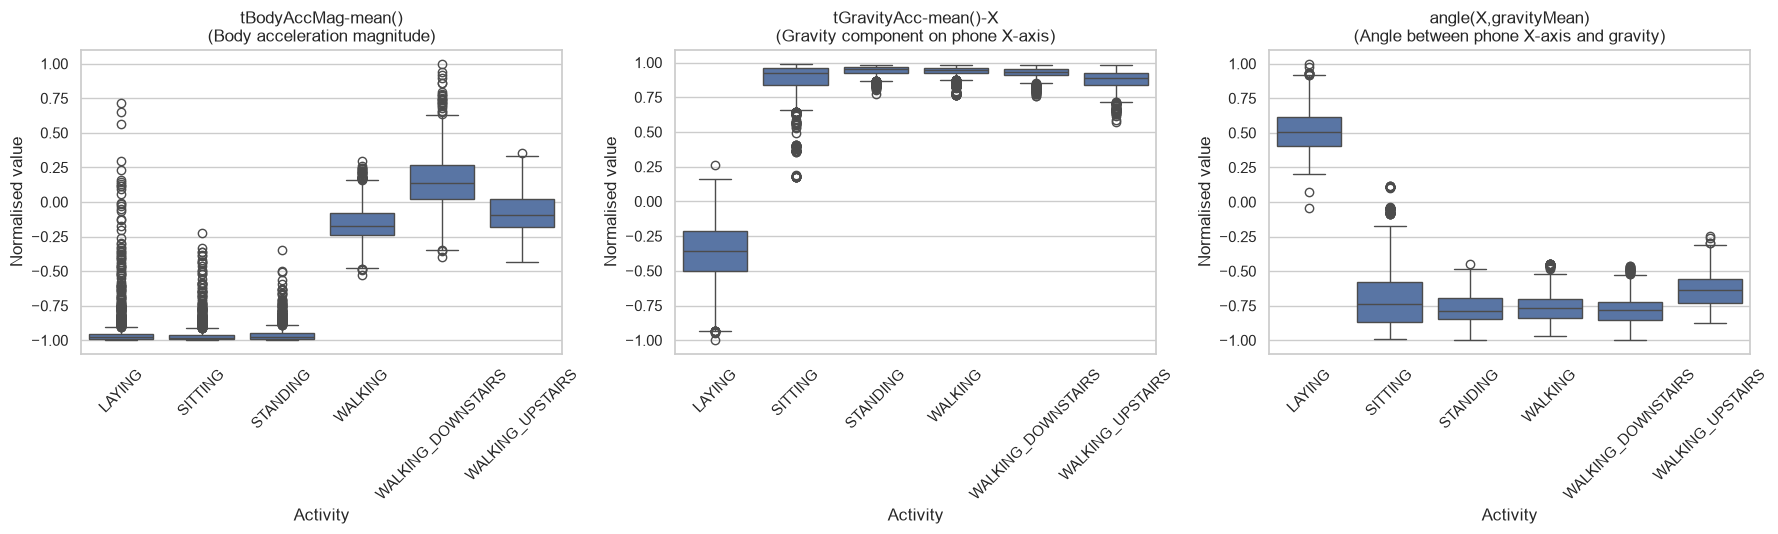

In [14]:
boxplot_features = {
    "tBodyAccMag-mean()": "Body acceleration magnitude",
    "tGravityAcc-mean()-X": "Gravity component on phone X-axis",
    "angle(X,gravityMean)": "Angle between phone X-axis and gravity",
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (feature, description) in zip(axes, boxplot_features.items()):
    sns.boxplot(data=train_df, x=TARGET, y=feature, order=activity_classes, ax=ax)
    ax.set_title(f"{feature}\n({description})")
    ax.set_xlabel("Activity")
    ax.set_ylabel("Normalised value")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [15]:
train_df.groupby(TARGET)[list(boxplot_features)].median().round(3)

,tBodyAccMag-mean(),tGravityAcc-mean()-X,"angle(X,gravityMean)"
Activity,,,
LAYING,-0.978,-0.358,0.509
SITTING,-0.985,0.926,-0.739
STANDING,-0.979,0.953,-0.791
WALKING,-0.173,0.943,-0.765
WALKING_DOWNSTAIRS,0.139,0.932,-0.784
WALKING_UPSTAIRS,-0.094,0.891,-0.633


### 2.8 Correlation Analysis

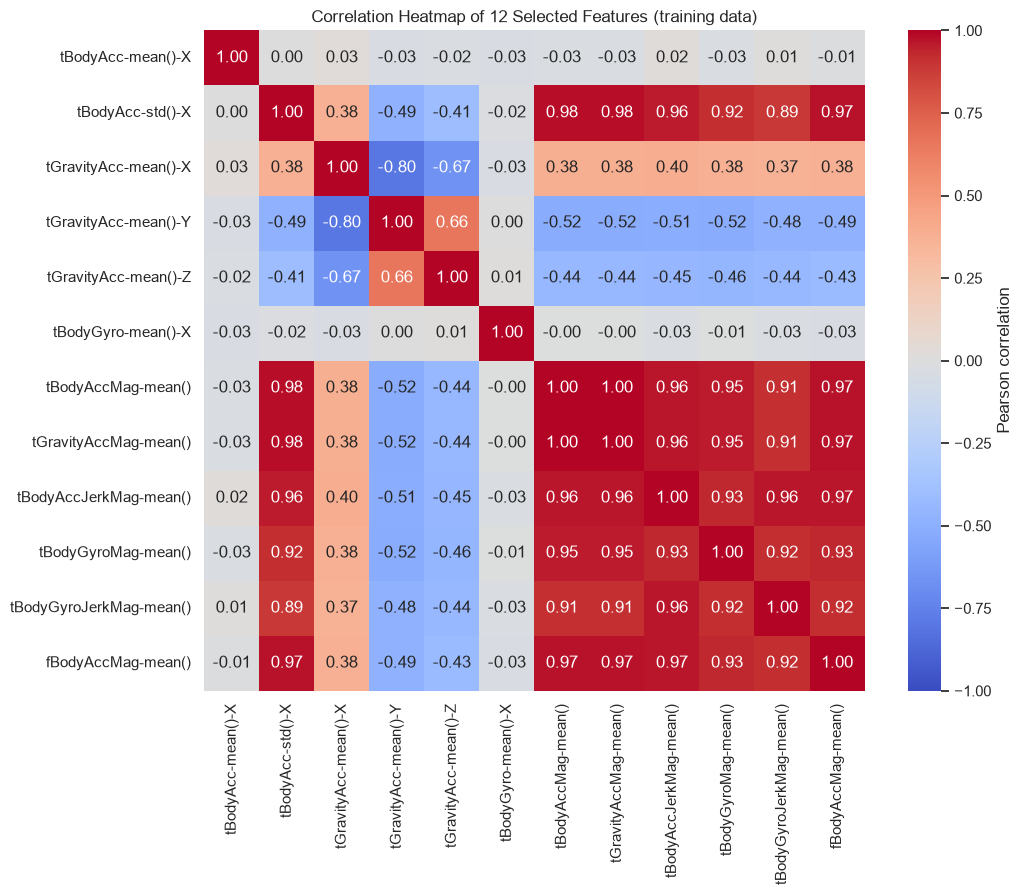

In [16]:
correlation_features = [
    "tBodyAcc-mean()-X", "tBodyAcc-std()-X", "tGravityAcc-mean()-X", "tGravityAcc-mean()-Y",
    "tGravityAcc-mean()-Z", "tBodyGyro-mean()-X", "tBodyAccMag-mean()", "tGravityAccMag-mean()",
    "tBodyAccJerkMag-mean()", "tBodyGyroMag-mean()", "tBodyGyroJerkMag-mean()", "fBodyAccMag-mean()",
]
correlation_matrix = train_df[correlation_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation Heatmap of 12 Selected Features (training data)")
plt.tight_layout()
plt.show()

In [17]:
full_corr = train_df[feature_columns].corr().abs()
upper_triangle = full_corr.where(np.triu(np.ones(full_corr.shape, dtype=bool), k=1))
n_pairs = upper_triangle.notna().sum().sum()
n_high = (upper_triangle > 0.9).sum().sum()
print(f"Feature pairs with |correlation| > 0.9: {n_high} of {n_pairs} ({n_high / n_pairs:.2%})")

Feature pairs with |correlation| > 0.9: 8206 of 157080 (5.22%)


### 2.9 EDA Insights

## 3. Data Preparation

### 3.1 Feature and Target Separation

In [18]:
X_train = train_df[feature_columns]
y_train = train_df[TARGET]

X_test = test_df[feature_columns]
y_test = test_df[TARGET]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
print("'subject' in features:", "subject" in feature_columns)

X_train: (7352, 561) | y_train: (7352,)
X_test:  (2947, 561) | y_test:  (2947,)
'subject' in features: False


### 3.2 Preprocessing

### 3.3 Train/Test Data

In [19]:
print(f"Training set: {len(X_train)} windows from {train_df['subject'].nunique()} subjects -> used for fitting")
print(f"Test set:     {len(X_test)} windows from {test_df['subject'].nunique()} subjects -> used ONLY for evaluation")

Training set: 7352 windows from 21 subjects -> used for fitting
Test set:     2947 windows from 9 subjects -> used ONLY for evaluation


## 4. Classification Models

In [20]:
results = {}
predictions = {}
trained_models = {}

def train_and_evaluate(model_name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    trained_models[model_name] = model
    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1-score (macro)": f1_score(y_test, y_pred, average="macro"),
        "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
    }

    print(f"===== {model_name} =====")
    for metric, value in results[model_name].items():
        print(f"{metric:<20}: {value:.4f}")
    print()
    print(classification_report(y_test, y_pred, digits=4))

### 4.1 Logistic Regression

In [21]:
log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
train_and_evaluate("Logistic Regression", log_reg_model)

===== Logistic Regression =====
Accuracy            : 0.9535
Precision (macro)   : 0.9563
Recall (macro)      : 0.9520
F1-score (macro)    : 0.9532
F1-score (weighted) : 0.9534
Train Accuracy      : 0.9963

                    precision    recall  f1-score   support

            LAYING     0.9981    0.9926    0.9953       537
           SITTING     0.9663    0.8758    0.9188       491
          STANDING     0.8898    0.9718    0.9290       532
           WALKING     0.9408    0.9940    0.9667       496
WALKING_DOWNSTAIRS     0.9899    0.9333    0.9608       420
  WALKING_UPSTAIRS     0.9529    0.9448    0.9488       471

          accuracy                         0.9535      2947
         macro avg     0.9563    0.9520    0.9532      2947
      weighted avg     0.9552    0.9535    0.9534      2947



### 4.2 Support Vector Machine

In [22]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])
train_and_evaluate("Support Vector Machine", svm_model)

===== Support Vector Machine =====
Accuracy            : 0.9518
Precision (macro)   : 0.9525
Recall (macro)      : 0.9504
F1-score (macro)    : 0.9511
F1-score (weighted) : 0.9517
Train Accuracy      : 0.9867

                    precision    recall  f1-score   support

            LAYING     0.9944    1.0000    0.9972       537
           SITTING     0.9383    0.8982    0.9178       491
          STANDING     0.9162    0.9455    0.9306       532
           WALKING     0.9602    0.9718    0.9659       496
WALKING_DOWNSTAIRS     0.9772    0.9190    0.9472       420
  WALKING_UPSTAIRS     0.9287    0.9682    0.9480       471

          accuracy                         0.9518      2947
         macro avg     0.9525    0.9504    0.9511      2947
      weighted avg     0.9522    0.9518    0.9517      2947



### 4.3 Random Forest

In [23]:
random_forest_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
train_and_evaluate("Random Forest", random_forest_model)

===== Random Forest =====
Accuracy            : 0.9291
Precision (macro)   : 0.9303
Recall (macro)      : 0.9263
F1-score (macro)    : 0.9275
F1-score (weighted) : 0.9289
Train Accuracy      : 1.0000

                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       537
           SITTING     0.9156    0.8839    0.8995       491
          STANDING     0.8962    0.9248    0.9103       532
           WALKING     0.9043    0.9718    0.9368       496
WALKING_DOWNSTAIRS     0.9680    0.8643    0.9132       420
  WALKING_UPSTAIRS     0.8977    0.9130    0.9053       471

          accuracy                         0.9291      2947
         macro avg     0.9303    0.9263    0.9275      2947
      weighted avg     0.9302    0.9291    0.9289      2947



## 5. Comparative Performance Analysis

### 5.1 Evaluation Metrics

### 5.2 Model Comparison

In [24]:
comparison_table = pd.DataFrame(results).T
comparison_table.index.name = "Model"
main_metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]
comparison_table[main_metrics].round(4)

,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
Model,,,,
Logistic Regression,0.9535,0.9563,0.9520,0.9532
Support Vector Machine,0.9518,0.9525,0.9504,0.9511
Random Forest,0.9291,0.9303,0.9263,0.9275


In [25]:
print("Highest value for each metric:")
for metric in main_metrics:
    print(f"  {metric:<18}: {comparison_table[metric].idxmax():<24} ({comparison_table[metric].max():.4f})")

print("\nWeighted F1 (reference) and overfitting check (train accuracy - test accuracy):")
overfit_check = comparison_table[["F1-score (weighted)", "Train Accuracy", "Accuracy"]].copy()
overfit_check["Train-Test gap"] = overfit_check["Train Accuracy"] - overfit_check["Accuracy"]
overfit_check.round(4)

Highest value for each metric:
  Accuracy          : Logistic Regression      (0.9535)
  Precision (macro) : Logistic Regression      (0.9563)
  Recall (macro)    : Logistic Regression      (0.9520)
  F1-score (macro)  : Logistic Regression      (0.9532)

Weighted F1 (reference) and overfitting check (train accuracy - test accuracy):


,F1-score (weighted),Train Accuracy,Accuracy,Train-Test gap
Model,,,,
Logistic Regression,0.9534,0.9963,0.9535,0.0428
Support Vector Machine,0.9517,0.9867,0.9518,0.0349
Random Forest,0.9289,1.0000,0.9291,0.0709


### 5.3 Confusion Matrices

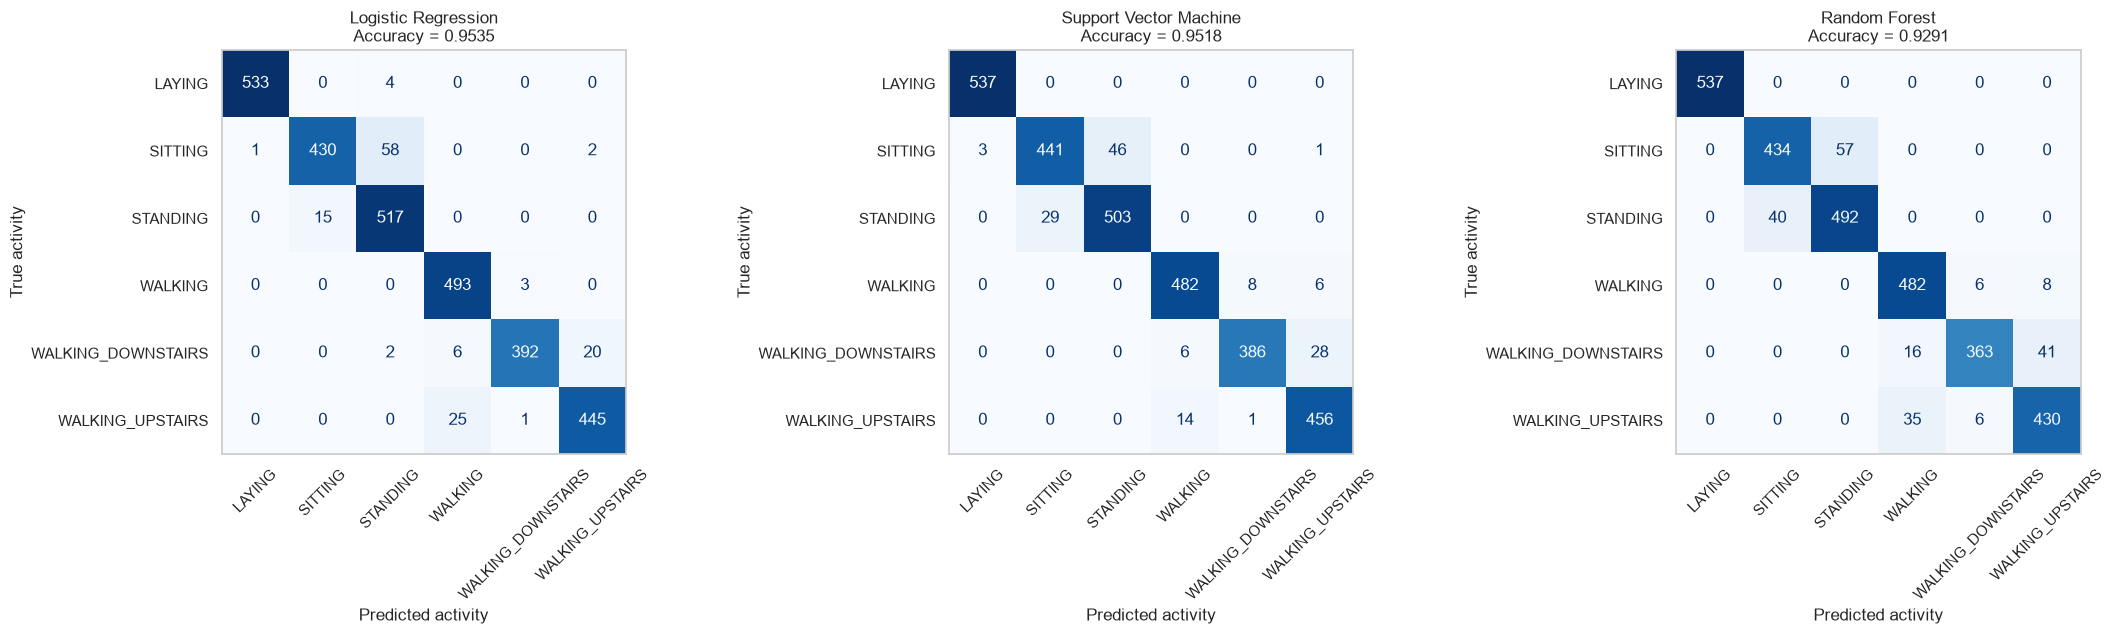

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
confusion_matrices = {}
for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=activity_classes)
    confusion_matrices[model_name] = cm
    ConfusionMatrixDisplay(cm, display_labels=activity_classes).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{model_name}\nAccuracy = {results[model_name]['Accuracy']:.4f}")
    ax.set_xlabel("Predicted activity")
    ax.set_ylabel("True activity")
    ax.grid(False)
plt.tight_layout()
plt.show()

In [27]:
per_class_recall = pd.DataFrame(
    {name: cm.diagonal() / cm.sum(axis=1) for name, cm in confusion_matrices.items()},
    index=activity_classes,
)
per_class_recall["Mean over models"] = per_class_recall.mean(axis=1)
per_class_recall.sort_values("Mean over models").round(4)

,Logistic Regression,Support Vector Machine,Random Forest,Mean over models
SITTING,0.8758,0.8982,0.8839,0.8859
WALKING_DOWNSTAIRS,0.9333,0.9190,0.8643,0.9056
WALKING_UPSTAIRS,0.9448,0.9682,0.9130,0.9420
STANDING,0.9718,0.9455,0.9248,0.9474
WALKING,0.9940,0.9718,0.9718,0.9792
LAYING,0.9926,1.0000,1.0000,0.9975


In [28]:
for model_name, cm in confusion_matrices.items():
    errors = pd.DataFrame(cm, index=activity_classes, columns=activity_classes)
    errors = errors.stack().rename("count").reset_index()
    errors.columns = ["True activity", "Predicted as", "count"]
    errors = errors[errors["True activity"] != errors["Predicted as"]]
    top_errors = errors.sort_values("count", ascending=False).head(4)
    print(f"--- {model_name}: total errors = {errors['count'].sum()} of {cm.sum()} ---")
    print(top_errors.to_string(index=False))
    print()

--- Logistic Regression: total errors = 137 of 2947 ---
     True activity     Predicted as  count
           SITTING         STANDING     58
  WALKING_UPSTAIRS          WALKING     25
WALKING_DOWNSTAIRS WALKING_UPSTAIRS     20
          STANDING          SITTING     15

--- Support Vector Machine: total errors = 142 of 2947 ---
     True activity     Predicted as  count
           SITTING         STANDING     46
          STANDING          SITTING     29
WALKING_DOWNSTAIRS WALKING_UPSTAIRS     28
  WALKING_UPSTAIRS          WALKING     14

--- Random Forest: total errors = 209 of 2947 ---
     True activity     Predicted as  count
           SITTING         STANDING     57
WALKING_DOWNSTAIRS WALKING_UPSTAIRS     41
          STANDING          SITTING     40
  WALKING_UPSTAIRS          WALKING     35



In [29]:
static_activities = ["LAYING", "SITTING", "STANDING"]
y_test_is_static = y_test.isin(static_activities).to_numpy()
for model_name, y_pred in predictions.items():
    cross_group_errors = (y_test_is_static != np.isin(y_pred, static_activities)).sum()
    print(f"{model_name:<24}: static <-> dynamic errors = {cross_group_errors}")

lr_svm_disagreements = (predictions["Logistic Regression"] != predictions["Support Vector Machine"]).sum()
print(f"\nTest windows where Logistic Regression and SVM predict different activities: {lr_svm_disagreements}")

Logistic Regression     : static <-> dynamic errors = 4
Support Vector Machine  : static <-> dynamic errors = 1
Random Forest           : static <-> dynamic errors = 0

Test windows where Logistic Regression and SVM predict different activities: 117


### 5.4 Performance Comparison

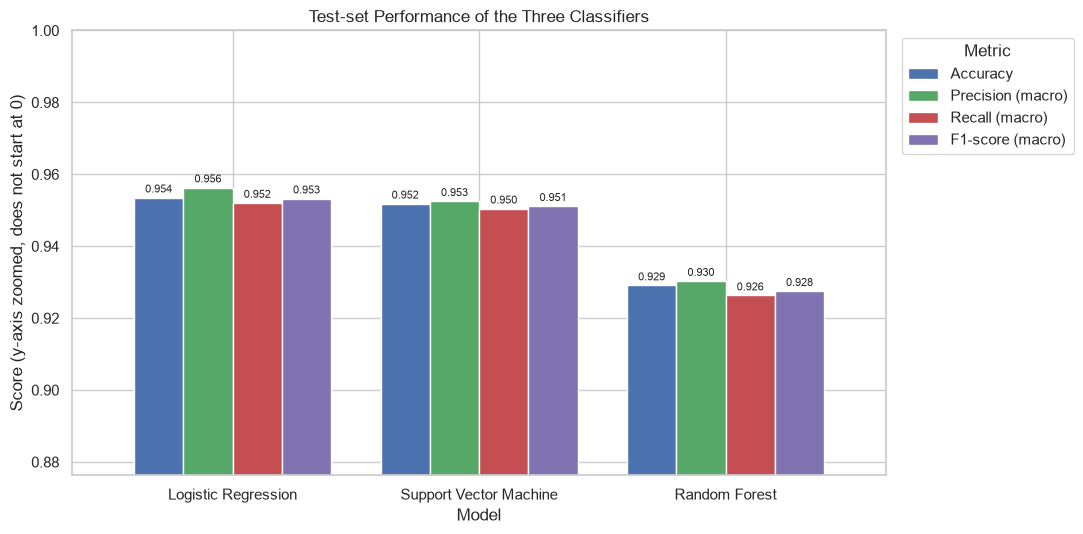

In [30]:
ax = comparison_table[main_metrics].plot(kind="bar", figsize=(11, 5.5), width=0.8,
                                          color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
lowest = comparison_table[main_metrics].min().min()
ax.set_ylim(max(0, lowest - 0.05), 1.0)
ax.set_title("Test-set Performance of the Three Classifiers")
ax.set_xlabel("Model")
ax.set_ylabel("Score (y-axis zoomed, does not start at 0)")
ax.legend(title="Metric", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()